# Lab 07

## Full Name: Nguyễn Phúc Minh Châu

## Student ID:  22302421

In [13]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

### a. The dataset has missing data. Show the percentage of missing data for each feature/column in **‘recipe_missing.csv’** and then plot in a bar chart.

In [11]:
#Load dataset of 'recipe_missing.csv'
m_df = pd.read_csv('recipe_missing.csv')
m_df.head()

,Style,StyleID,Size(L),OG,FG,ABV,IBU,Color,BoilSize,BoilTime
0,Cream Ale,45,21.77,1.055,1.013,5.48,17.65,4.83,28.39,75.0
1,Holiday/Winter Special Spiced Beer,85,20.82,1.083,1.021,8.16,60.65,15.64,24.61,60.0
2,American IPA,7,18.93,1.063,1.018,5.91,59.25,8.98,22.71,60.0
3,American IPA,7,22.71,1.061,1.017,5.80,54.48,NaN,26.50,60.0
4,Belgian Blond Ale,20,50.00,1.060,1.010,6.48,17.84,4.57,60.00,90.0


In [12]:
#Mising Count
missing_count = m_df.isnull().sum()
#Missing Count %
missing_percentage = (missing_count / len(m_df)) * 100

#Display Missing Data Table
missing_dt = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percentage.round(2)})
missing_dt

,Missing Count,Missing Percentage
Style,2,2.02
StyleID,0,0.00
Size(L),0,0.00
OG,0,0.00
FG,0,0.00
ABV,0,0.00
IBU,0,0.00
Color,12,12.12
BoilSize,9,9.09
BoilTime,10,10.10


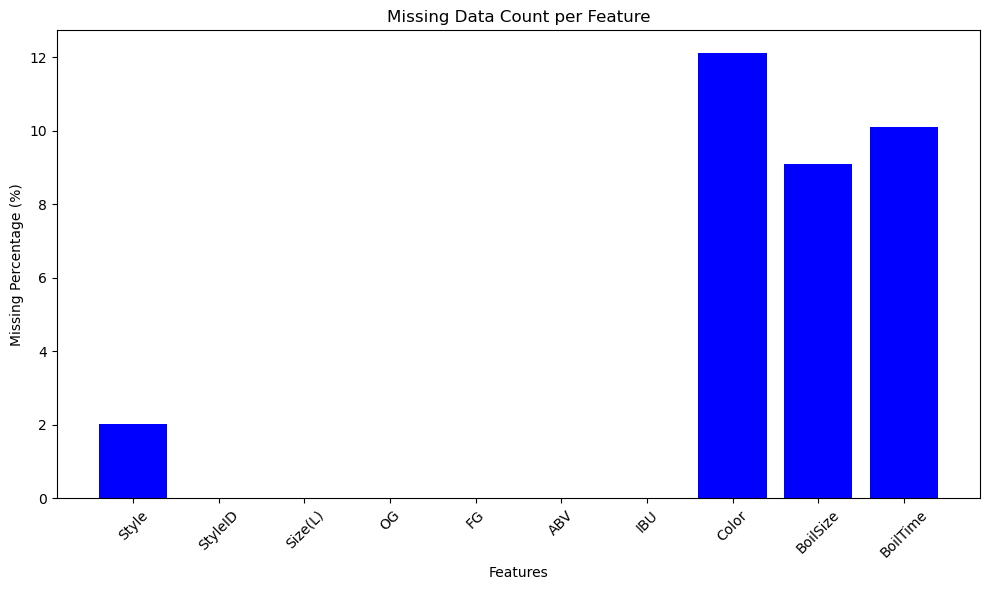

In [19]:
#Barchart Plot of Missing Data
plt.figure(figsize=(10,6))
plt.bar(missing_dt.index, missing_dt['Missing Percentage'], color='blue')
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Data Count per Feature')
plt.tight_layout()
plt.show()

### b. Use KNNImputer, k = 5. Plot the histogram of imputed data and original data of the last 3 columns. Compute the Mean Square Error (MSE) between original data and imputed data.

In [3]:
#Load original dataset of 'recipe.csv'
df = pd.read_csv('recipe.csv')
df.head()

,Style,StyleID,Size(L),OG,FG,ABV,IBU,Color,BoilSize,BoilTime
0,Cream Ale,45,21.77,1.055,1.013,5.48,17.65,4.83,28.39,75
1,Holiday/Winter Special Spiced Beer,85,20.82,1.083,1.021,8.16,60.65,15.64,24.61,60
2,American IPA,7,18.93,1.063,1.018,5.91,59.25,8.98,22.71,60
3,American IPA,7,22.71,1.061,1.017,5.80,54.48,8.50,26.50,60
4,Belgian Blond Ale,20,50.00,1.060,1.010,6.48,17.84,4.57,60.00,90


In [4]:
#Separate Label and Numeric Features
label = df[['Style']]
numeric_df = df.select_dtypes(include=['float64', 'int64'])
#KNN Imputer for Numeric Features, k =5
imputer = KNNImputer(n_neighbors=5)
numeric_imputer = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)
df_imputed = pd.concat([label, numeric_imputer], axis=1)
df_imputed.head()

,Style,StyleID,Size(L),OG,FG,ABV,IBU,Color,BoilSize,BoilTime
0,Cream Ale,45.0,21.77,1.055,1.013,5.48,17.65,4.83,28.39,75.0
1,Holiday/Winter Special Spiced Beer,85.0,20.82,1.083,1.021,8.16,60.65,15.64,24.61,60.0
2,American IPA,7.0,18.93,1.063,1.018,5.91,59.25,8.98,22.71,60.0
3,American IPA,7.0,22.71,1.061,1.017,5.80,54.48,8.50,26.50,60.0
4,Belgian Blond Ale,20.0,50.00,1.060,1.010,6.48,17.84,4.57,60.00,90.0


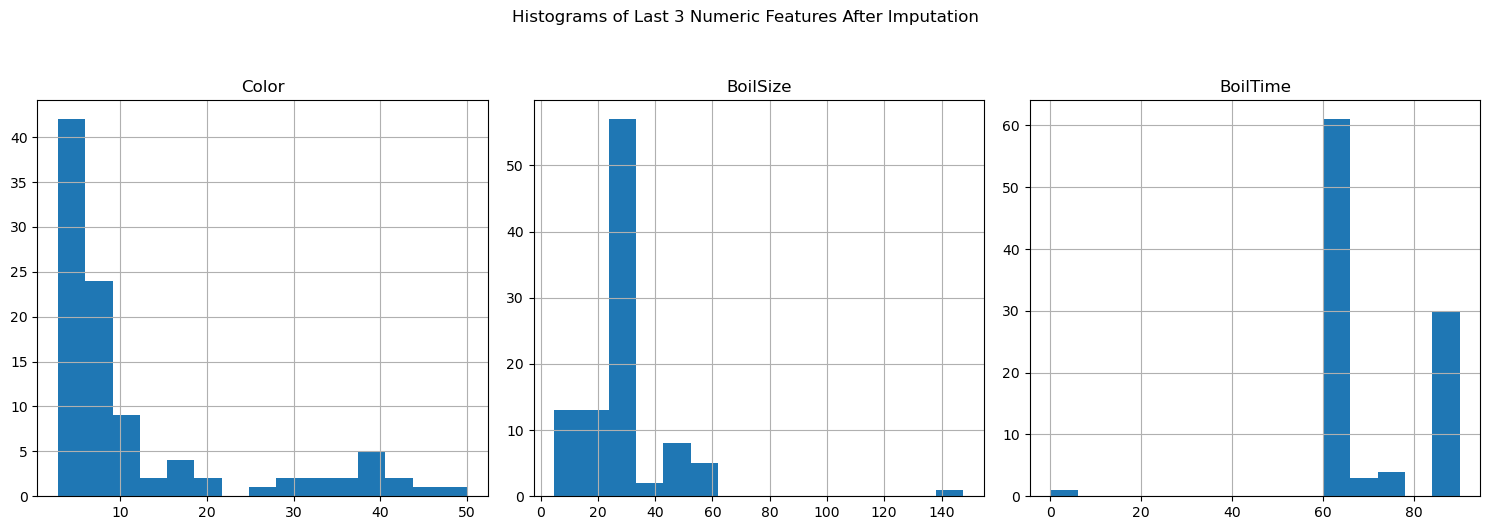

In [5]:
#Select 3 last collumns of df_imputed
last_3_col = df_imputed.iloc[:, -3:]

# Draw histograms for the last 3 columns
last_3_col.hist(bins=15, figsize=(15, 5), layout=(1, 3))
plt.suptitle('Histograms of Last 3 Numeric Features After Imputation', y=1.05)
plt.tight_layout()
plt.show()

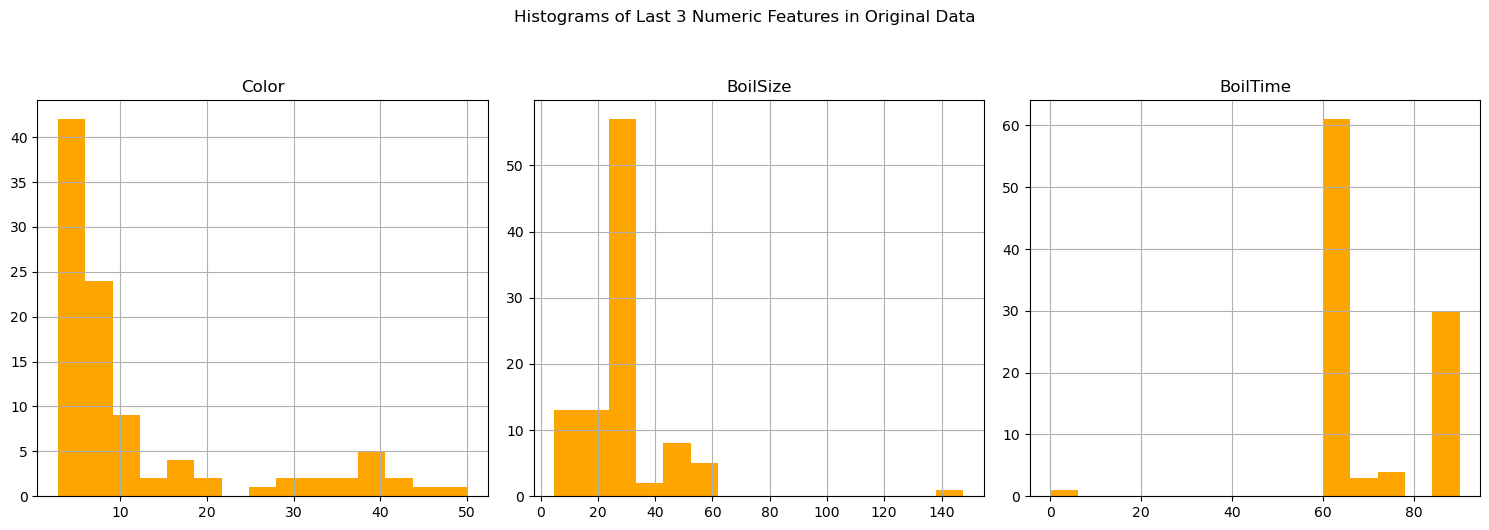

In [7]:
#Select 3 last collumns of df
last_3_col_original = df.iloc[:, -3:]
# Draw histograms for the last 3 columns of original data
last_3_col_original.hist(bins=15, figsize=(15, 5), layout=(1, 3), color='orange')
plt.suptitle('Histograms of Last 3 Numeric Features in Original Data', y=1.05)
plt.tight_layout()
plt.show()

**<u>Notice:</u>**
Mean Squared Error **(MSE)** measures the average of the squared differences between predicted (imputed) values and actual values.

$$ MSE = 1/n \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$

In [10]:
#Compute mse between original and imputed for last 3 columns
mse_values = {}
for col in last_3_col.columns:
    mse = mean_squared_error(last_3_col_original[col], last_3_col[col])
    mse_values[col] = mse
mse_values

{'Color': 0.0, 'BoilSize': 0.0, 'BoilTime': 0.0}

### c. Use MICE algorithm for 10 cycles. Initialize missing data using **SimpleImputer**, using **“mean”** strategy. For each cycle, fill in the missing place using **IterativeImputer** and estimator=**DecisionTree Regressor**. Plot the histogram of imputed data and original data of the last 3 columns. Compute the Mean Square Error (MSE) between original data and imputed data.

In [ ]:
# Seperate numeric data
num_m_df = m_df.select_dtypes(include=['float64', 'int64'])

# Initialize missing data using SimpleImputer with "mean" strategy
simple_imputer = SimpleImputer(strategy='mean')
mice_data = pd.DataFrame(simple_imputer.fit_transform(num_m_df), columns=num_m_df.columns)
# MICE Imputer with DecisionTreeRegressor for 10 cycles
mice_imputer = IterativeImputer(estimator=DecisionTreeRegressor(), max_iter=10, random_state=0)
mice_imputed = pd.DataFrame(mice_imputer.fit_transform(mice_data), columns=mice_data.columns)

mice_imputed.head()

,StyleID,Size(L),OG,FG,ABV,IBU,Color,BoilSize,BoilTime
0,45.0,21.77,1.055,1.013,5.48,17.65,4.830000,28.39,75.0
1,85.0,20.82,1.083,1.021,8.16,60.65,15.640000,24.61,60.0
2,7.0,18.93,1.063,1.018,5.91,59.25,8.980000,22.71,60.0
3,7.0,22.71,1.061,1.017,5.80,54.48,12.744138,26.50,60.0
4,20.0,50.00,1.060,1.010,6.48,17.84,4.570000,60.00,90.0


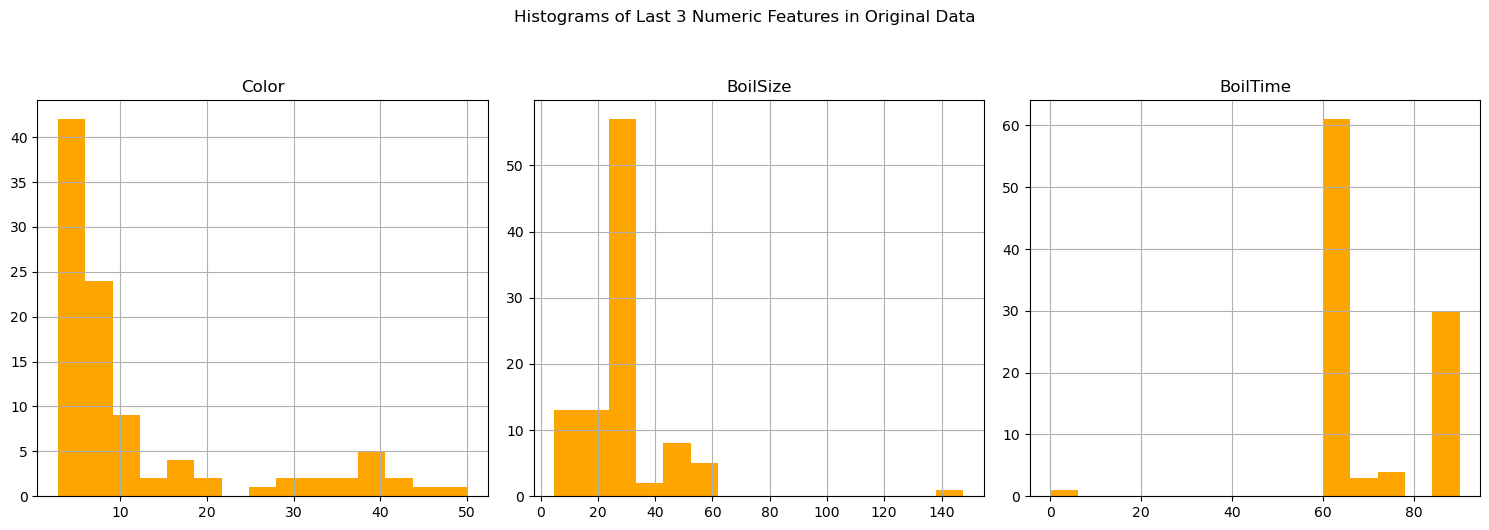

In [20]:
#Select 3 last collumns of df
last_3_col_original = df.iloc[:, -3:]
# Draw histograms for the last 3 columns of original data
last_3_col_original.hist(bins=15, figsize=(15, 5), layout=(1, 3), color='orange')
plt.suptitle('Histograms of Last 3 Numeric Features in Original Data', y=1.05)
plt.tight_layout()
plt.show()

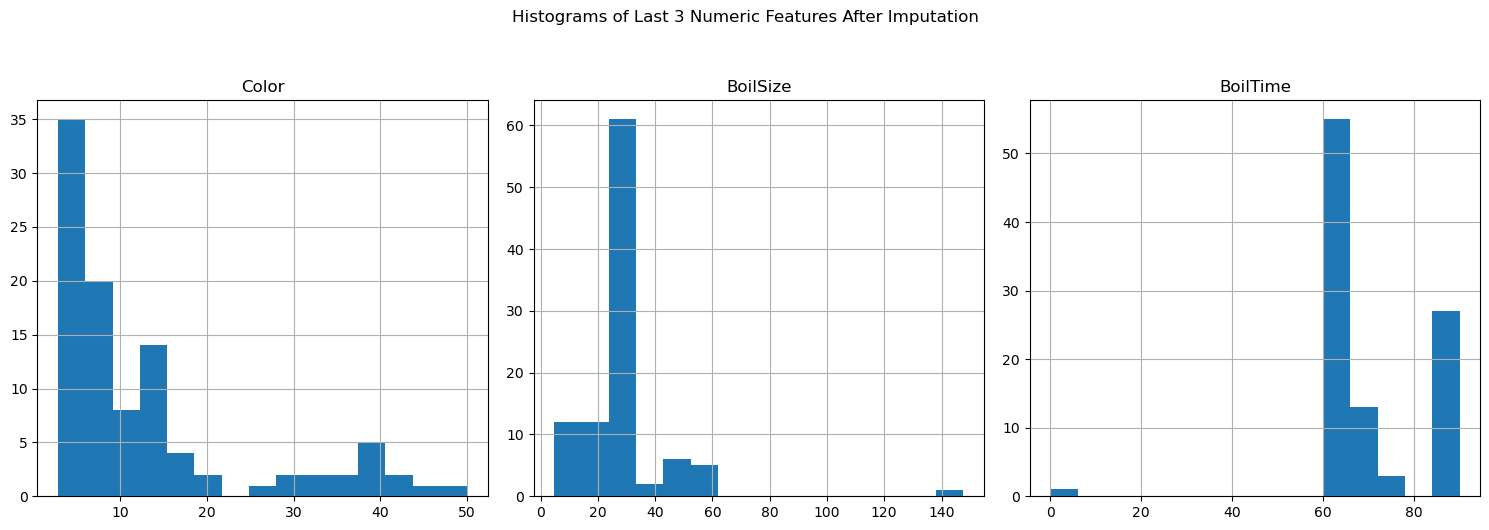

In [21]:
#Select 3 last collumns of mice_imputed
last_3_col = mice_imputed.iloc[:, -3:]

# Draw histograms for the last 3 columns
last_3_col.hist(bins=15, figsize=(15, 5), layout=(1, 3))
plt.suptitle('Histograms of Last 3 Numeric Features After Imputation', y=1.05)
plt.tight_layout()
plt.show()

In [22]:
#Compute mse between original and imputed for last 3 columns
mse_values = {}
for col in last_3_col.columns:
    mse = mean_squared_error(last_3_col_original[col], last_3_col[col])
    mse_values[col] = mse
mse_values

{'Color': 6.250557979317547,
 'BoilSize': 14.311319444444445,
 'BoilTime': 18.561992861323752}